In [1]:
import numpy as np
import matplotlib
import pandas as pd
import tensorflow as tf

dataset = pd.read_csv('/Users/eddie/Downloads/lake_erie_habs_W4_6_8_9_12_13_16_2013-2020.csv')

dataset['Chorophyll-a'].isna()

train = dataset.iloc[:743,:]
test = dataset.iloc[743:,:]
print(train)
print(test)
X_train = pd.DataFrame(train.iloc[:,4:15].values)
Y_train = train.iloc[:,16:].values
print(X_train.shape)
print(Y_train.shape)
X_test = pd.DataFrame(test.iloc[:,4:15].values)
Y_test = test.iloc[:,16:].values
print(X_test.shape)
print(Y_test.shape)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



          Date  Latitude   Longitude   Secchi Depth   CTD Temperature  \
0    5/29/2013    41.7134    -83.3804           1.60             18.5   
1    5/29/2013    41.8343    -83.3633           1.00             20.3   
2    5/29/2013    41.8267    -83.1930           1.50             19.8   
3    6/10/2013    41.7144    -83.3805           0.50             20.7   
4    6/10/2013    41.8353    -83.3631           0.70             23.5   
..         ...        ...         ...            ...              ...   
738  10/7/2019    41.6599    -83.1467           1.00             18.2   
739  10/7/2019    41.7428    -83.1354           1.25             18.2   
740  10/7/2019    41.7023    -83.2639           1.25             18.5   
741  10/7/2019    41.8270    -83.1949           1.50             17.2   
742  6/16/2020    41.7054    -83.3864           0.20             20.3   

     CTD Specific Conductivity   CTD Dissolved Oxygen   Turbidity   \
0                         391.3                   7.6

In [2]:
features = pd.DataFrame(dataset.iloc[:,4:15])
features = features.columns
print(features)

Index(['CTD Temperature', 'CTD Specific Conductivity ',
       'CTD Dissolved Oxygen ', 'Turbidity ', 'Total Phosphorus',
       'Total Dissolved Phosphorus ', 'Ammonia', 'Nitrate + Nitrite ',
       'Particulate Organic Carbon ', 'Particulate Organic Nitrogen ',
       'Total Suspended Solids'],
      dtype='object')


In [3]:
from keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dropout, Dense, BatchNormalization, GRU, LayerNormalization, MultiHeadAttention,TimeDistributed, Input, Flatten
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor 

In [4]:
# Initialize Random Forest regressor
model = DecisionTreeRegressor(random_state=42)

# Train the model
model.fit(X_train, Y_train)




DecisionTreeRegressor(random_state=42)

In [5]:
res = model.predict(X_test)
res.reshape(96,1)
print(res)
print(res.shape)

[ 0.77 49.79  2.84 10.67  5.21  4.59 19.29  6.73  6.73  4.59  1.27 34.02
  6.73 23.92  5.09 56.01  8.88 46.46 19.7  18.5   8.8  67.44  6.19  8.8
 13.17  9.69 67.44 33.12 63.91 10.53 13.36 38.4   1.27 38.4  26.   55.04
 18.81 11.01 11.96  4.65 33.15 26.   88.48 26.91 37.75 26.    5.95 33.15
 42.47 88.92 37.75  7.48  9.07  7.77 20.28 33.88 46.46 22.55  7.74 26.
  5.95 16.    8.81 21.56 11.58  7.97 18.18  1.89 32.51 26.   14.56 16.63
 11.12 26.    3.52 16.   20.28 19.27 18.18 26.   26.    2.77 13.45 16.63
 18.49 19.37 10.76 11.12  3.86 10.76  6.29  6.89  3.54  2.14 10.76  2.68]
(96,)


In [6]:
res = model.predict(X_test)
print(res)

from sklearn.metrics import r2_score 
r2 = r2_score(Y_test, res) 
print(r2)
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(Y_test,res)
print(mae)
from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(Y_test,res)
print(mape)
from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(Y_test,res)
print(rmse)


[ 0.77 49.79  2.84 10.67  5.21  4.59 19.29  6.73  6.73  4.59  1.27 34.02
  6.73 23.92  5.09 56.01  8.88 46.46 19.7  18.5   8.8  67.44  6.19  8.8
 13.17  9.69 67.44 33.12 63.91 10.53 13.36 38.4   1.27 38.4  26.   55.04
 18.81 11.01 11.96  4.65 33.15 26.   88.48 26.91 37.75 26.    5.95 33.15
 42.47 88.92 37.75  7.48  9.07  7.77 20.28 33.88 46.46 22.55  7.74 26.
  5.95 16.    8.81 21.56 11.58  7.97 18.18  1.89 32.51 26.   14.56 16.63
 11.12 26.    3.52 16.   20.28 19.27 18.18 26.   26.    2.77 13.45 16.63
 18.49 19.37 10.76 11.12  3.86 10.76  6.29  6.89  3.54  2.14 10.76  2.68]
0.7233100259262168
6.709791666666667
0.4645014932665455
9.628333189083145


c:\Users\eddie\anaconda3\envs\SSTP-Injury\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


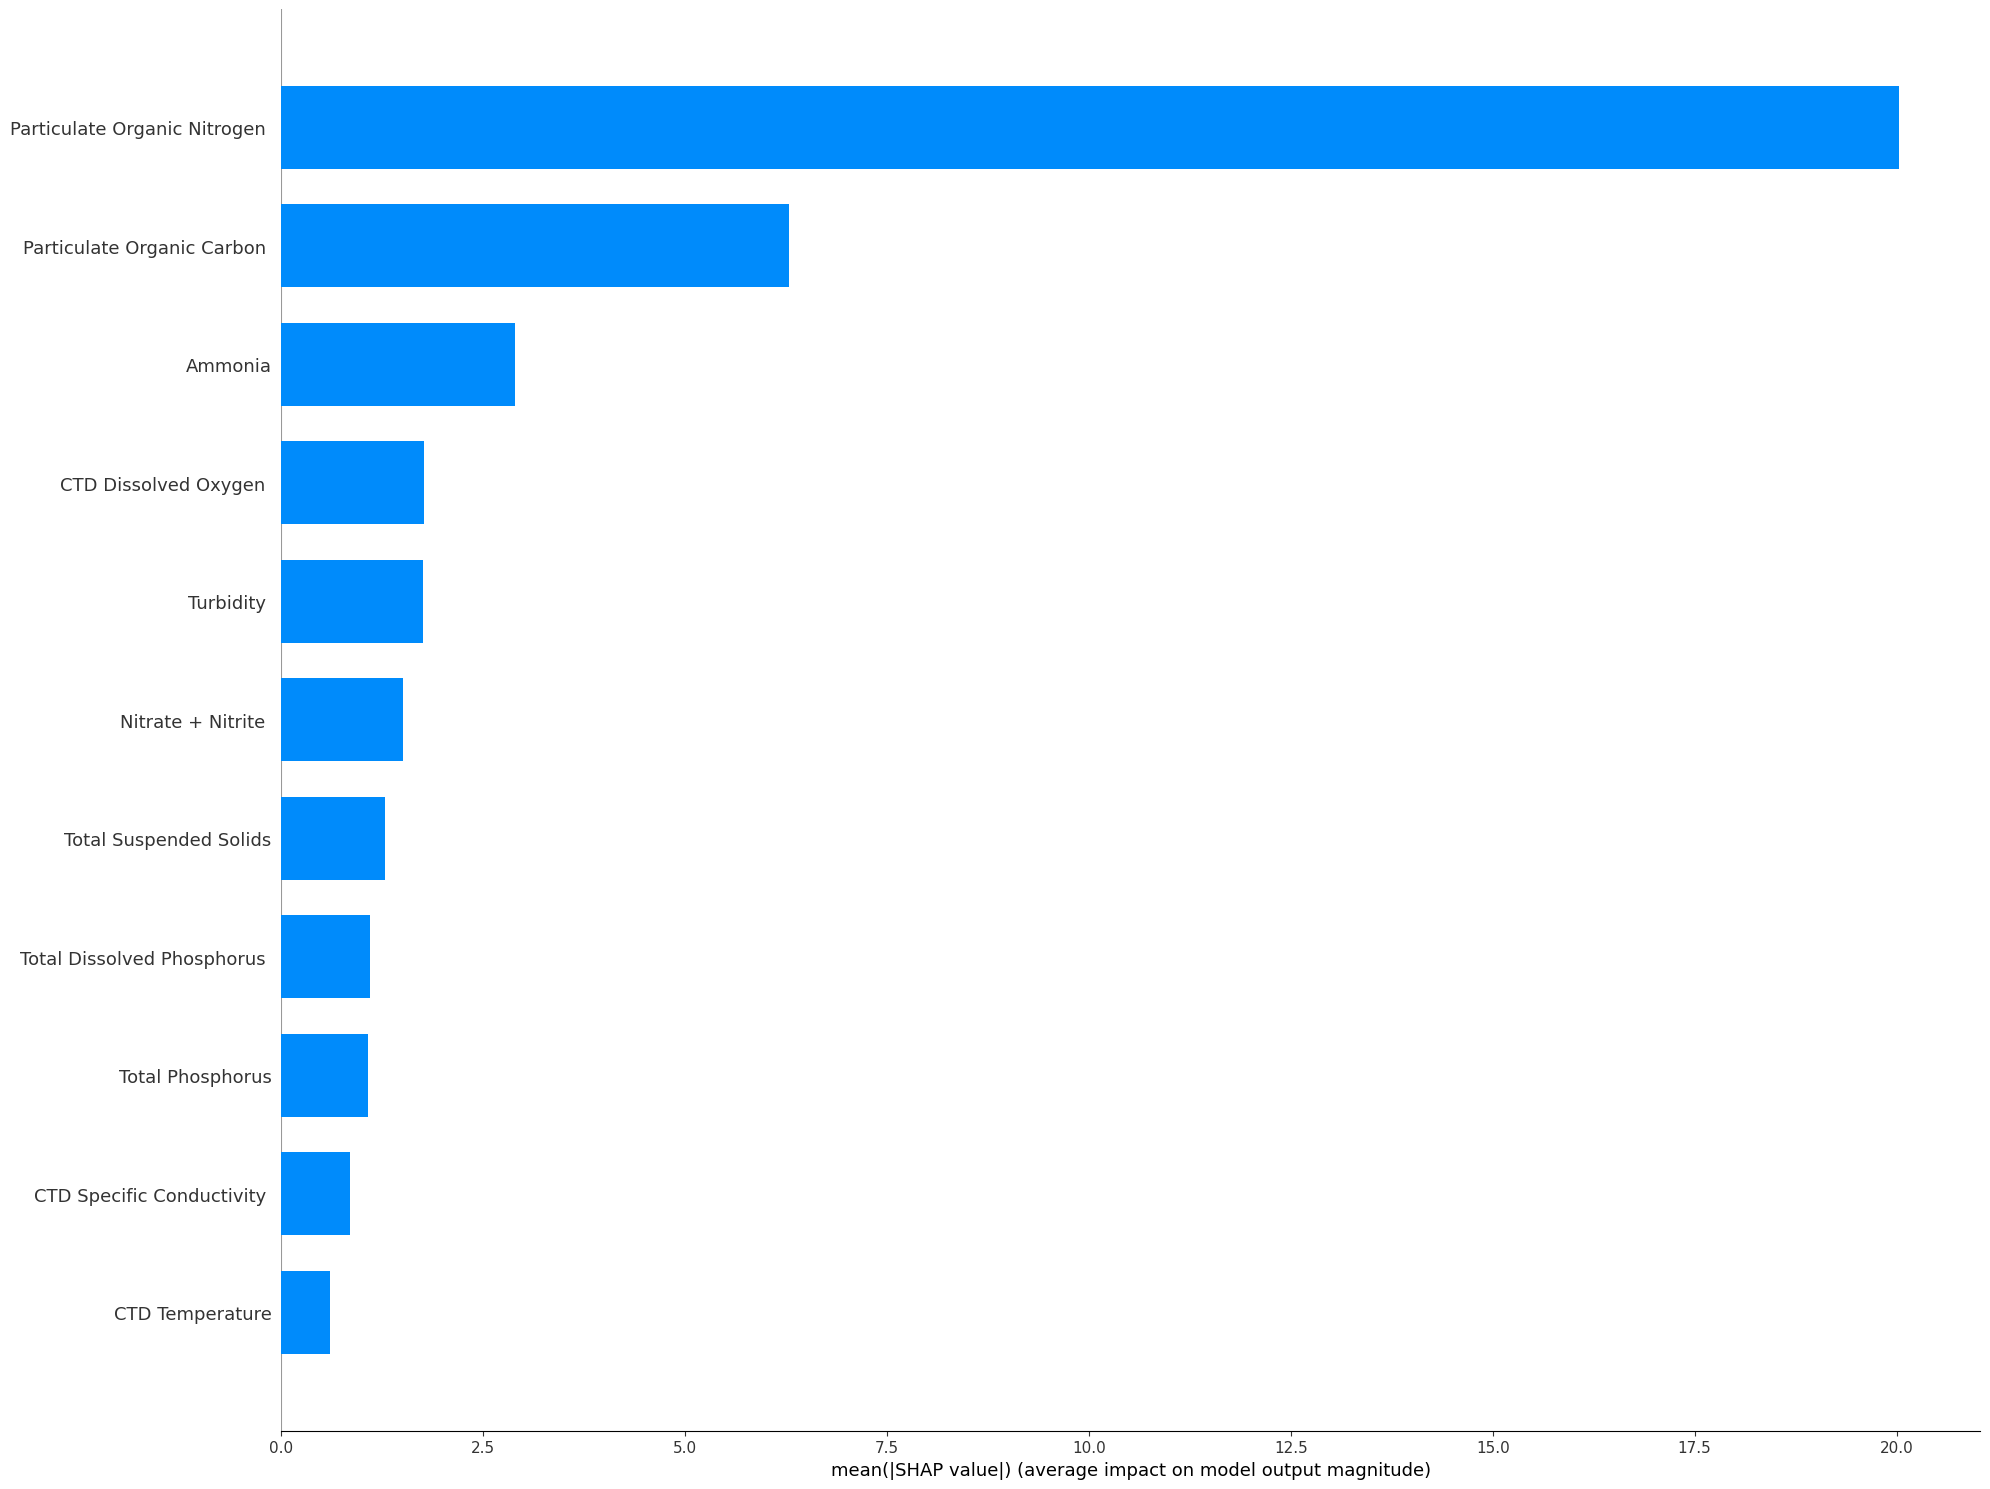

In [7]:
import shap
explainer = shap.Explainer(model)
shap_values = explainer.shap_values(X_train)
import matplotlib.pyplot as plt 
shap.summary_plot(shap_values, X_train,feature_names = features,plot_size=(20,15),plot_type="bar",show=False)


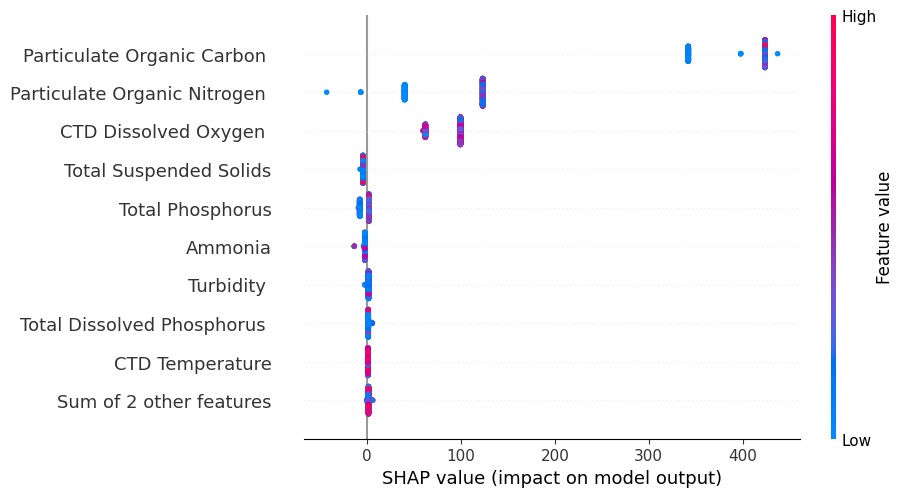

In [8]:
X_test_shap = pd.DataFrame(train.iloc[:,4:15])
shap_values = explainer(X_test_shap)
shap.plots.beeswarm(shap_values=shap_values)

In [9]:
print(shap_values)

.values =
array([[  0.88832009,   0.7960817 ,  62.08649724, ..., 342.06161133,
         40.05318165,  -4.37621823],
       [  0.88832009,   0.7960817 ,  62.08649724, ..., 342.06161133,
         40.05318165,  -4.37621823],
       [  0.88832009,   0.7960817 ,  62.08649724, ..., 342.06161133,
         40.05318165,  -4.37621823],
       ...,
       [  0.9046531 ,   0.80262188,  62.03249938, ..., 342.20440819,
         40.19597851,  -4.36964254],
       [  0.90338796,   0.80197114,  62.07902843, ..., 342.0310743 ,
         40.02264462,  -4.3711091 ],
       [  0.88832009,   0.7960817 ,  62.08649724, ..., 342.06161133,
         40.05318165,  -4.37621823]])

.base_values =
array([31.73426649, 31.73426649, 31.73426649, 31.73426649, 31.73426649,
       31.73426649, 31.73426649, 31.73426649, 31.73426649, 31.73426649,
       31.73426649, 31.73426649, 31.73426649, 31.73426649, 31.73426649,
       31.73426649, 31.73426649, 31.73426649, 31.73426649, 31.73426649,
       31.73426649, 31.73426649, 31.7